In [1]:
import numpy as np
import pandas as pd

from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
SEASON_MAP = {
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Autumn",
    10: "Autumn",
    11: "Autumn",
}

TIME_BINS = [-1, 5, 9, 14, 19, 24]
TIME_LABELS = ["Night", "Morning_Rush", "Day", "Afternoon_Rush", "Evening"]

AGE_MAP = {
    "0 to 4": "Child",
    "5 to 9": "Child",
    "10 to 14": "Child",
    "15 to 19": "Young_Adult",
    "20 to 24": "Young_Adult",
    "25 to 29": "Adult",
    "30 to 34": "Adult",
    "35 to 39": "Adult",
    "40 to 44": "Adult",
    "45 to 49": "Adult",
    "50 to 54": "Adult",
    "55 to 59": "Adult",
    "60 to 64": "Adult",
    "65 to 69": "Senior",
    "70 to 74": "Senior",
    "75 to 79": "Senior",
    "80 to 84": "Senior",
    "85 to 89": "Senior",
    "90 to 94": "Senior",
    "Over 95": "Senior",
    "unknown": "Unknown",
    "Unknown": "Unknown",
}

PEDCOND_GROUPED_MAPPING = {
    "Unknown": "unknown",
    "Normal": "normal",
    "Inattentive": "inattentive",
    "Had Been Drinking": "substance_impaired",
    "Ability Impaired, Alcohol": "substance_impaired",
    "Ability Impaired, Drugs": "substance_impaired",
    "Ability Impaired, Alcohol Over .80": "substance_impaired",
    "Medical or Physical Disability": "medical_issue",
    "Fatigue": "medical_issue",
    "Other": "other",
}

DRIVCOND_GROUPED_MAPPING = {
    "Unknown": "unknown",
    "Normal": "normal",
    "Inattentive": "inattentive",
    "Had Been Drinking": "substance_impaired",
    "Ability Impaired, Alcohol": "substance_impaired",
    "Ability Impaired, Alcohol Over .08": "substance_impaired",
    "Ability Impaired, Drugs": "substance_impaired",
    "Medical or Physical Disability": "medical_issue",
    "Fatigue": "medical_issue",
    "Other": "other",
}

PEDACT_GROUPED_MAPPING = {
    "Unknown": "unknown",
    "Crossing with right of way": "crossing",
    "Crossing, no Traffic Control": "crossing",
    "Crossing without right of way": "crossing",
    "Crossing, Pedestrian Crossover": "crossing",
    "Crossing marked crosswalk without ROW": "crossing",
    "Walking on Roadway with Traffic": "walking_roadway",
    "Walking on Roadway Against Traffic": "walking_roadway",
    "Running onto Roadway": "sudden_entry",
    "Coming From Behind Parked Vehicle": "sudden_entry",
    "On Sidewalk or Shoulder": "sidewalk_shoulder",
    "Person Getting on/off Vehicle": "vehicle_related",
    "Person Getting on/off School Bus": "vehicle_related",
    "Pushing/Working on Vehicle": "vehicle_related",
    "Playing or Working on Highway": "other",
    "Other": "other",
}

PEDESTRIAN_GROUPED_MAPPING = {
    "Pedestrian hit at mid-block": "mid_block",
    "Vehicle hits the pedestrian walking or running out from between parked vehicles at mid-block": "mid_block",
    "Pedestrian hit a PXO/ped. Mid-block signal": "mid_block",
    "Vehicle turns left while ped crosses with ROW at inter.": "intersection_turning",
    "Vehicle turns left while ped crosses without ROW at inter.": "intersection_turning",
    "Vehicle turns right while ped crosses with ROW at inter.": "intersection_turning",
    "Vehicle turns right while ped crosses without ROW at inter.": "intersection_turning",
    "Vehicle is going straight thru inter.while ped cross with ROW": "intersection_straight",
    "Vehicle is going straight thru inter.while ped cross without ROW": "intersection_straight",
    "Pedestrian hit on sidewalk or shoulder": "sidewalk_shoulder",
    "Pedestrian hit at private driveway": "private_property",
    "Pedestrian hit at parking lot": "private_property",
    "Vehicle is reversing and hits pedestrian": "reversing",
    "Pedestrian involved in a collision with transit vehicle anywhere along roadway": "transit_collision",
    "Unknown": "unknown",
    "Other / Undefined": "other",
}

CYCLISTYPE_GROUPED_MAPPING = {
    "Unknown": "unknown",
    "Insufficient information (to determine cyclist crash type).": "unknown",
    "Motorist turned left across cyclists path.": "motorist_turn_conflict",
    "Motorist turns right at non-signal Inter.(stop, yield, no cont.,and dwy) and strikes cyclist.": "motorist_turn_conflict",
    "Motorist turning right on green or amber at signalized intersection strikes cyclist.": "motorist_turn_conflict",
    "Motorist turning right on red at signalized intersection strikes cyclist.": "motorist_turn_conflict",
    "Motorist makes u-turn in-front of cyclist.": "motorist_turn_conflict",
    "Cyclist turned left across motorists path.": "cyclist_turn_conflict",
    "Cyclist turns right across motorists path": "cyclist_turn_conflict",
    "Cyclist makes u-turn in-front of driver.": "cyclist_turn_conflict",
    "Cyclist without ROW rides into path of motorist at inter, lnwy, dwy-Cyclist not turn.": "row_violation",
    "Motorist without ROW drives into path of cyclist at inter, lnwy, dwy-Driver not turn.": "row_violation",
    "Cyclist and Driver travelling in same direction. One vehicle sideswipes the other.": "same_direction_collision",
    "Cyclist and Driver travelling in same direction. One vehicle rear-ended the other.": "same_direction_collision",
    "Cyclist struck opened vehicle door": "dooring",
    "Cyclist loses control and strikes object (pole, ttc track)": "cyclist_loss_control",
    "Cyclist falls off bike - no contact with motorist.": "cyclist_loss_control",
    "Cyclist strikes a parked vehicle.": "cyclist_loss_control",
    "Cyclist rode off sidewalk into road at midblock.": "midblock_entry",
    "Motorist reversing struck cyclist.": "reversing_collision",
    "Motorist loses control and strikes cyclist.": "reversing_collision",
    "Cyclist strikes pedestrian.": "pedestrian_conflict",
    "Cyclist struck at PXO(cyclist either travel in same dir. as veh. or ride across xwalk)": "crossing_facility",
}

ROW_DROP_COLUMNS = [
    "OBJECTID",
    "INDEX",
    "STREET1",
    "STREET2",
    "OFFSET",
    "LATITUDE",
    "LONGITUDE",
    "INJURY",
    "FATAL_NO",
    "VEHTYPE",
    "HOOD_158",
    "HOOD_140",
    "NEIGHBOURHOOD_140",
    "DIVISION",
    "x",
    "y",
    "NEIGHBOURHOOD_158",
]

GROUPED_COLUMNS_TO_DROP = ["PEDCOND", "DRIVCOND", "PEDACT", "PEDTYPE", "CYCLISTYPE"]

In [3]:
def _build_accident_split(data, test_size=0.2, random_state=42):
    accident_labels = (
        data.assign(FATAL_ACCIDENT=(data["ACCLASS"] == "Fatal").astype(int))
        .groupby("ACCNUM", as_index=False)["FATAL_ACCIDENT"]
        .max()
    )
    train_ids, test_ids = train_test_split(
        accident_labels["ACCNUM"],
        test_size=test_size,
        random_state=random_state,
        stratify=accident_labels["FATAL_ACCIDENT"],
    )
    return set(train_ids), set(test_ids)


def _fill_missing_values(X_train, X_test):
    fill_values = {}
    for column in X_train.columns:
        if not X_train[column].isnull().any():
            continue
        if pd.api.types.is_numeric_dtype(X_train[column]):
            fill_values[column] = X_train[column].median()
        else:
            unique_values = set(X_train[column].dropna().astype(str).unique())
            fill_values[column] = "No" if "Yes" in unique_values else "Unknown"
    X_train = X_train.fillna(fill_values)
    X_test = X_test.fillna(fill_values)
    return X_train, X_test


def _add_time_features(frame):
    frame = frame.copy()
    frame["DATE"] = pd.to_datetime(frame["DATE"])
    frame["TIME"] = pd.to_numeric(frame["TIME"], errors="coerce").fillna(0)
    frame["HOUR"] = frame["TIME"] // 100
    frame["SEASON"] = frame["DATE"].dt.month.map(SEASON_MAP)
    frame["IS_WEEKEND"] = frame["DATE"].dt.dayofweek.apply(lambda value: 1 if value >= 5 else 0)
    frame["TIME_RANGE"] = pd.cut(frame["HOUR"], bins=TIME_BINS, labels=TIME_LABELS)
    frame["AGE_GROUP"] = frame["INVAGE"].map(AGE_MAP).fillna("Unknown")
    return frame


def _add_grouped_columns(frame):
    frame = frame.copy()
    frame["PEDCOND_GRP"] = frame["PEDCOND"].map(PEDCOND_GROUPED_MAPPING).fillna("other")
    frame["DRIVCOND_GRP"] = frame["DRIVCOND"].map(DRIVCOND_GROUPED_MAPPING).fillna("other")
    frame["PEDACT_GRP"] = frame["PEDACT"].map(PEDACT_GROUPED_MAPPING).fillna("other")
    frame["PEDTYPE_GRP"] = frame["PEDTYPE"].map(PEDESTRIAN_GROUPED_MAPPING).fillna("other")
    frame["CYCLISTYPE_GRP"] = frame["CYCLISTYPE"].map(CYCLISTYPE_GROUPED_MAPPING).fillna("other")
    return frame


def _preprocess_rows(X_train, X_test):
    X_train = X_train.fillna('Unknown')
    X_test = X_test.fillna('Unknown')

    for frame in [X_train, X_test]:
        cat_cols = frame.select_dtypes(include=['object']).columns
        for col in cat_cols:
            frame[col] = frame[col].astype(str).str.strip()

    X_train = _add_time_features(X_train)
    X_test = _add_time_features(X_test)
    
    for frame in [X_train, X_test]:
        frame['hour_sin'] = np.sin(2 * np.pi * frame['HOUR'] / 24.0)
        frame['hour_cos'] = np.cos(2 * np.pi * frame['HOUR'] / 24.0)

    X_train = _add_grouped_columns(X_train)
    X_test = _add_grouped_columns(X_test)

    # Удаляем старые колонки времени и возраста
    cols_to_drop = ["DATE", "TIME", "HOUR", "INVAGE"] + GROUPED_COLUMNS_TO_DROP
    X_train = X_train.drop(columns=cols_to_drop)
    X_test = X_test.drop(columns=cols_to_drop)

    X_train_encoded = pd.get_dummies(X_train, drop_first=True)
    X_test_encoded = pd.get_dummies(X_test, drop_first=True)

    cols_to_remove = [c for c in X_train_encoded.columns if '_Unknown' in c or '_nan' in c or '_unknown' in c]
    X_train_encoded.drop(columns=cols_to_remove, inplace=True, errors='ignore')
    X_test_encoded.drop(columns=cols_to_remove, inplace=True, errors='ignore')

    X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join="left", axis=1, fill_value=0)
    return X_train_encoded.fillna(0), X_test_encoded.fillna(0)


def _aggregate_accident_features(X_encoded, accident_ids):
    temp_df = X_encoded.copy()
    temp_df["ACCNUM"] = accident_ids.values
    
    all_cols = [c for c in X_encoded.columns if c != "ACCNUM"]
    
    columns_to_sum = [col for col in all_cols if any(prefix in col for prefix in 
                     ['INVTYPE_', 'DRIVACT_', 'CYCACT_', 'PEDACT_', 'DRIVCOND_', 'PEDCOND_', 
                      'MANOEUVER_', 'IMPACTYPE_', 'CYCCOND_'])]
    
    columns_to_max = [col for col in all_cols if col not in columns_to_sum]
    
    agg_funcs = {col: 'sum' for col in columns_to_sum}
    agg_funcs.update({col: 'max' for col in columns_to_max})
    
    accident_features = temp_df.groupby("ACCNUM").agg(agg_funcs)
    
    participant_count = accident_ids.value_counts().rename("PARTICIPANT_COUNT")
    accident_features["PARTICIPANT_COUNT"] = participant_count.reindex(accident_features.index).fillna(0)
    
    return accident_features.sort_index()



def _aggregate_accident_target(y_rows, accident_ids):
    accident_target = (
        pd.DataFrame({"ACCNUM": accident_ids.values, "FATAL_ACCIDENT": (y_rows == "Fatal").astype(int).values})
        .groupby("ACCNUM", as_index=True)["FATAL_ACCIDENT"]
        .max()
        .sort_index()
    )
    return accident_target


def prepare_accident_level_data(csv_path="TOTAL_KSI_3737821728629277523.csv", test_size=0.2, random_state=42):
    data = pd.read_csv(csv_path)
    data = data[data["ACCNUM"].notna() & data["ACCLASS"].notna()].copy()

    train_accidents, test_accidents = _build_accident_split(
        data,
        test_size=test_size,
        random_state=random_state,
    )

    train_rows = data[data["ACCNUM"].isin(train_accidents)].copy()
    test_rows = data[data["ACCNUM"].isin(test_accidents)].copy()

    train_accnum = train_rows["ACCNUM"].copy()
    test_accnum = test_rows["ACCNUM"].copy()

    data_new_train = train_rows.drop(columns=ROW_DROP_COLUMNS)
    data_new_test = test_rows.drop(columns=ROW_DROP_COLUMNS)

    X_train_rows = data_new_train.drop(columns=["ACCLASS", "ACCNUM"])
    X_test_rows = data_new_test.drop(columns=["ACCLASS", "ACCNUM"])
    y_train_rows = train_rows["ACCLASS"]
    y_test_rows = test_rows["ACCLASS"]

    X_train_encoded, X_test_encoded = _preprocess_rows(X_train_rows, X_test_rows)

    X_train_accident = _aggregate_accident_features(X_train_encoded, train_accnum)
    X_test_accident = _aggregate_accident_features(X_test_encoded, test_accnum)
    y_train_accident = _aggregate_accident_target(y_train_rows, train_accnum)
    y_test_accident = _aggregate_accident_target(y_test_rows, test_accnum)

    X_train_accident, X_test_accident = X_train_accident.align(
        X_test_accident,
        join="left",
        axis=1,
        fill_value=0,
    )
    y_test_accident = y_test_accident.reindex(X_test_accident.index)
    y_train_accident = y_train_accident.reindex(X_train_accident.index)

    scaler = StandardScaler()

    X_train_acc_scaled = scaler.fit_transform(X_train_accident)
    X_test_acc_scaled = scaler.transform(X_test_accident)

    # Чтобы сохранить имена колонок (StandardScaler возвращает numpy array), 
    # можно обернуть обратно в DataFrame, если хочешь видеть графики потом
    X_train_final = pd.DataFrame(X_train_acc_scaled, columns=X_train_accident.columns, index=X_train_accident.index)
    X_test_final = pd.DataFrame(X_test_acc_scaled, columns=X_test_accident.columns, index=X_test_accident.index)

    return X_train_final, X_test_final, y_train_accident.astype(int), y_test_accident.astype(int)

if __name__ == "__main__":
    X_train_acc, X_test_acc, y_train_acc, y_test_acc = prepare_accident_level_data()
    
    for df in [X_train_acc, X_test_acc]:
        df['VULNERABILITY_SENIOR_PED'] = df['AGE_GROUP_Senior'] * df['PEDESTRIAN_Yes']
        df['BLIND_SPOT_CRASH'] = df['PEDTYPE_GRP_private_property'] * df['MANOEUVER_Overtaking']
        df['TRUCK_EXCEEDS_LIMIT'] = df['DRIVACT_Exceeding Speed Limit'] * df['INVTYPE_Truck Driver']
        df['FATAL_COMBO_RAIN_SPEED'] = df['VISIBILITY_Rain'] * df['DRIVACT_Speed too Fast For Condition']
    
    
    X_train_final = X_train_acc.astype("float32")
    y_train_final = y_train_acc.astype("float32")
    X_test_final = X_test_acc.astype("float32")
    y_test_final = y_test_acc.astype("float32")

    print(X_train_final.shape[0])


3963


In [4]:
xgb_model = XGBClassifier(
    n_estimators=300, 
    max_depth=10, 
    learning_rate=0.2, 
    random_state=42
)

xgb_model.fit(X_train_final, y_train_final)
xgb_pred_probs = xgb_model.predict_proba(X_test_final)[:, 1]
xgb_preds = (xgb_pred_probs > 0.25).astype(int)

print(confusion_matrix(y_test_final, xgb_preds))
print(classification_report(y_test_final, xgb_preds, target_names=['Non-Fatal (0)', 'Fatal (1)']))

[[811  55]
 [100  25]]
               precision    recall  f1-score   support

Non-Fatal (0)       0.89      0.94      0.91       866
    Fatal (1)       0.31      0.20      0.24       125

     accuracy                           0.84       991
    macro avg       0.60      0.57      0.58       991
 weighted avg       0.82      0.84      0.83       991



In [5]:
feature_importances = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n top-15 most important features")
print(feature_importances.head(15))


 top-15 most important features
                           Feature  Importance
180            TRUCK_EXCEEDS_LIMIT    0.051074
44     DRIVACT_Following too Close    0.031636
69                  CYCCOND_Normal    0.019304
122         LIGHT_Dawn, artificial    0.019149
67             CYCCOND_Inattentive    0.017717
60                    CYCACT_Other    0.016416
121                     LIGHT_Dawn    0.015948
75      DRIVCOND_GRP_medical_issue    0.015471
178       VULNERABILITY_SENIOR_PED    0.015080
139                    CYCLIST_Yes    0.014701
73               PEDCOND_GRP_other    0.014464
7              IMPACTYPE_Sideswipe    0.014459
37   MANOEUVER_Slowing or Stopping    0.012988
77              DRIVCOND_GRP_other    0.012902
105  TRAFFCTL_Pedestrian Crossover    0.012505


In [6]:
TOP_N = 80
top_features = feature_importances['Feature'].head(TOP_N).tolist()

X_train_top = X_train_final[top_features]
X_test_top = X_test_final[top_features]

model_top = Sequential([
    Input(shape=(X_train_top.shape[1],)),
    
    Dense(64, activation='swish'),
    BatchNormalization(),
    Dropout(0.2), 

    Dense(32, activation='gelu'),
    BatchNormalization(),

    Dense(32, activation='gelu'),
    
    Dense(1, activation='sigmoid')
])

model_top.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
#early_stop = EarlyStopping(patience=7, restore_best_weights=True)

class_weight = {0: 1, 1: 6} 

history_top = model_top.fit(
    X_train_top, y_train_final, 
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight,
    #callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5915 - loss: 1.1285 - val_accuracy: 0.6456 - val_loss: 0.6622
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step - accuracy: 0.6801 - loss: 1.0154 - val_accuracy: 0.6721 - val_loss: 0.6236
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step - accuracy: 0.7085 - loss: 0.9555 - val_accuracy: 0.6683 - val_loss: 0.6271
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - accuracy: 0.7252 - loss: 0.9046 - val_accuracy: 0.6507 - val_loss: 0.6325
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 747us/step - accuracy: 0.7391 - loss: 0.8658 - val_accuracy: 0.6595 - val_loss: 0.6362
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 729us/step - accuracy: 0.7448 - loss: 0.8394 - val_accuracy: 0.6608 - val_loss: 0.6327
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 742us/step - accuracy: 0.7748 - loss: 0.8177 - val_accuracy: 0.6683 - val_loss: 0.6258
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step - accuracy: 0.7628 - loss: 0.7926 - va

In [7]:
y_pred_probs_top = model_top.predict(X_test_top).ravel()
precisions, recalls, thresholds = precision_recall_curve(y_test_final, y_pred_probs_top)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"best_threshold : {best_threshold:.3f}")
print(f"best_f1: {best_f1:.3f}")
print(f"Precision = {precisions[best_idx]:.3f}, Recall = {recalls[best_idx]:.3f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
best_threshold : 0.201
best_f1: 0.332
Precision = 0.224, Recall = 0.640


In [8]:
y_pred_probs_top = model_top.predict(X_test_top)
y_pred_top = (y_pred_probs_top > best_threshold).astype(int)

print(confusion_matrix(y_test_final, y_pred_top))
print(classification_report(y_test_final, y_pred_top, target_names=['Non-Fatal (0)', 'Fatal (1)']))

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 447us/step
[[589 277]
 [ 46  79]]
               precision    recall  f1-score   support

Non-Fatal (0)       0.93      0.68      0.78       866
    Fatal (1)       0.22      0.63      0.33       125

     accuracy                           0.67       991
    macro avg       0.57      0.66      0.56       991
 weighted avg       0.84      0.67      0.73       991



31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step
🚀 Running 100 bootstrapping iterations...

--- AVERAGED METRICS FOR FATAL (1) OVER 100 RUNS ---
Precision: 0.228
Recall:    0.600
F1-score:  0.330 (± 0.025 standard deviation)



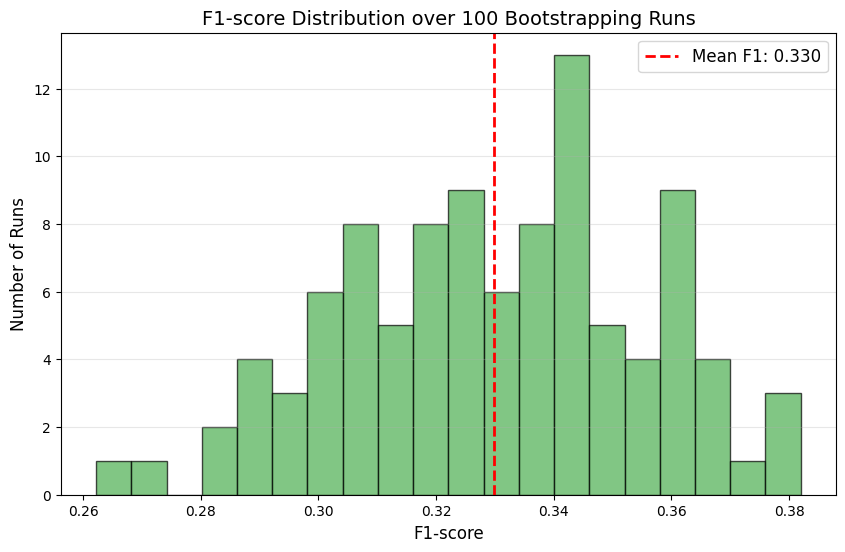

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import resample
from sklearn.metrics import precision_recall_fscore_support

n_iterations = 100

precisions_fatal = []
recalls_fatal = []
f1s_fatal = []

y_pred_probs_top = model_top.predict(X_test_top)
y_pred_top = (y_pred_probs_top > best_threshold).astype(int)

print(f"🚀 Running {n_iterations} bootstrapping iterations...\n")

for i in range(n_iterations):
    y_test_boot, y_pred_boot = resample(
        y_test_final, y_pred_top, random_state=i
    )

    p, r, f, _ = precision_recall_fscore_support(
        y_test_boot, y_pred_boot, labels=[0, 1], zero_division=0
    )

    precisions_fatal.append(p[1])
    recalls_fatal.append(r[1])
    f1s_fatal.append(f[1])

mean_f1 = np.mean(f1s_fatal)
std_f1 = np.std(f1s_fatal)

print("--- AVERAGED METRICS FOR FATAL (1) OVER 100 RUNS ---")
print(f"Precision: {np.mean(precisions_fatal):.3f}")
print(f"Recall:    {np.mean(recalls_fatal):.3f}")
print(f"F1-score:  {mean_f1:.3f} (± {std_f1:.3f} standard deviation)\n")

plt.figure(figsize=(10, 6))
plt.hist(f1s_fatal, bins=20, color='#4CAF50', edgecolor='black', alpha=0.7)
plt.axvline(
    mean_f1,
    color='red',
    linestyle='dashed',
    linewidth=2,
    label=f'Mean F1: {mean_f1:.3f}'
)

plt.title('F1-score Distribution over 100 Bootstrapping Runs', fontsize=14)
plt.xlabel('F1-score', fontsize=12)
plt.ylabel('Number of Runs', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()